<a href="https://colab.research.google.com/github/raizelgestetner/ASL_fingerspelling/blob/main/levenshtein_distance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')


Mounted at /content/gdrive/


In [ ]:
pip install python-Levenshtein


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.4/177.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 26.5 MB/s eta 0:00:00


In [ ]:
# Function to calculate Levenshtein distance
def calculate_levenshtein_distance(expected, gotten):
    if pd.isna(expected):
        expected = ''
    if pd.isna(gotten):
        gotten = ''
    return Levenshtein.distance(expected, gotten)

In [ ]:
!ls /content/gdrive/MyDrive/ASL_fingerspelling_project

 101_project_book.gdoc			       final_presentation.pptx
'2nd TA Meeting - Raizel&Ilay - 101.gslides'   Group101_poster.pdf
'67547 24 schedule.pdf'			       helpful_code
 aslAppNew.mp4				       levenshtein_distance.ipynb
'ASL_evaluation - ASL_evaluation.csv'	       mileston2_ta_show.pptx
 ASL_evaluation.gsheet			      'Milestone 1  .gdoc'
 ASL_evaluation_out.csv			      'Milestone 3_ Demo Day Guidelines only.pdf'
 asl_poster.pptx			       milestone_3_take_1.mp4
 ASLtranslation.mp4			       milestone6photo.jpg
 data					       models
'Demo Day ASL.gslides'			       output.parquet
'Developing SignItOut 🤟.mp4'		      'Phenix American (1).mp4'
 final_presentation.mp4			       photo2parquet.ipynb


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import Levenshtein
import numpy as np

In [ ]:
# file path: levenshtein_distance.py




# Read the CSV file
input_file_path = "/content/gdrive/MyDrive/ASL_fingerspelling_project/ASL_evaluation - ASL_evaluation.csv"
output_file_path = '/content/gdrive/MyDrive/ASL_fingerspelling_project/ASL_evaluation_out.csv'

df = pd.read_csv(input_file_path)

# Read the CSV file
df = pd.read_csv(input_file_path)

# Calculate Levenshtein distance for each row using the appropriate columns
df['Levenshtein_Distance'] = df.apply(lambda row: calculate_levenshtein_distance(row['Expected'], row['Gotten']), axis=1)

# Calculate the length of the 'Expected' words
df['Expected_Length'] = df['Expected'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

# Calculate the total Levenshtein distance
average_distance = df['Levenshtein_Distance'].mean()
print(f"avarege Levenshtein Distance: {average_distance}")

# Save the results to a new CSV file
df.to_csv(output_file_path, index=False)

print(f"Levenshtein distances have been calculated and saved to {output_file_path}")
normilized = (df['Expected_Length'].sum() - df['Levenshtein_Distance'].sum() )/ df['Expected_Length'].sum()
print(f"Normelized levenshtain distance {normilized}")

avarege Levenshtein Distance: 1.891089108910891
Levenshtein distances have been calculated and saved to /content/gdrive/MyDrive/ASL_fingerspelling_project/ASL_evaluation_out.csv
Normelized levenshtain distance 0.7513020833333334


Levenshtein distances have been calculated and saved to /content/gdrive/MyDrive/ASL_fingerspelling_project/ASL_evaluation_out.csv


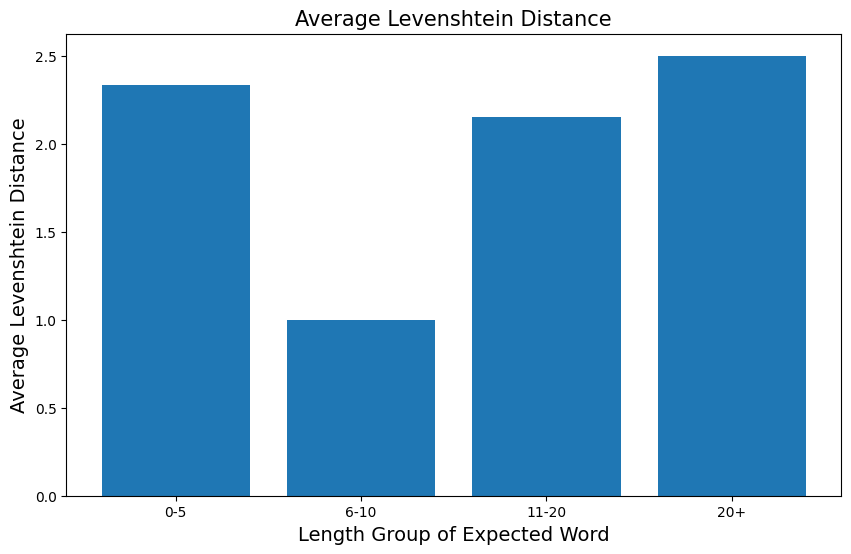

In [ ]:

# Bin the lengths into groups
# bins = [0, 2, 5, 8, 11, 14, 17, 20, np.inf]
# labels = ['0-2', '3-5', '6-8', '9-11', '12-14', '15-17', '18-20', '40+']
bins = [0,5, 10, 15, np.inf]
labels = ['0-5', '6-10', '11-20', '20+']
df['Length_Group'] = pd.cut(df['Expected_Length'], bins=bins, labels=labels, right=False)

# Group by the binned lengths and calculate the average Levenshtein distance
grouped_df = df.groupby('Length_Group')['Levenshtein_Distance'].mean().reset_index()

# Save the results to a new CSV file
df.to_csv(output_file_path, index=False)
print(f"Levenshtein distances have been calculated and saved to {output_file_path}")

# Plotting the graph
plt.figure(figsize=(10, 6))
plt.bar(grouped_df['Length_Group'], grouped_df['Levenshtein_Distance'])
plt.title('Average Levenshtein Distance', fontsize=15)
plt.xlabel('Length Group of Expected Word', fontsize=14)
plt.ylabel('Average Levenshtein Distance', fontsize=14)

plt.show()